# Final Project ML model 
## Due: March 14th 2026
### Names: Josral Frederick (30195360)
###        Erioluwa Olubadejo (30187041)
           


ACL injuries are one of the most serious injuries in soccer. They often require long rehabilitation
periods and can have lasting effects on a player’s physical and mental health. The problem we
are trying to solve for our client is to determine whether machine learning models can help
identify factors linked to ACL injuries and provide insights that could be useful for reducing
future injury risk.

### Necessary imports and setup code


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [128]:
# load raw data
with open("../data/Final-player.txt", "r", encoding="utf-8") as f:
    data = ast.literal_eval(f.read())

df = pd.DataFrame(data)

# keep backup
df_raw = df.copy()

# Make sure evrything loaded correctly 12 columns, 2580 rows
print(df.shape)

#previewing data
df.head()

(2580, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,238223,Ederson,Manchester City,"1,14 Bill. €",1993-08-17,89,"1,88",Brazil,Goalkeeper,left,"[(\nBenfica , \nMan City , 17/18, Jul 1, 2017)...","[(16/17, Meniscal Injury, 29)]"
1,40423,Claudio Bravo,Manchester City,"1,14 Bill. €",1983-04-13,84,"1,84",Chile,Goalkeeper,right,"[(\nFC Barcelona , \nMan City , 16/17, Aug 25,...","[(18/19, Achilles tendon rupture, 314), (16/17..."
2,371021,Arijanet Murić,Manchester City,"1,14 Bill. €",1998-11-07,-,"1,98",Kosovo,Goalkeeper,right,"[(\nNAC Breda , \nMan City , 18/19, Aug 22, 20...",[]
3,186590,John Stones,Manchester City,"1,14 Bill. €",1994-05-28,69,"1,88",England,Defender - Centre-Back,right,"[(\nEverton , \nMan City , 16/17, Aug 9, 2016)...","[(18/19, Muscle Injury, 6), (17/18, Minor Knoc..."
4,176553,Aymeric Laporte,Manchester City,"1,14 Bill. €",1994-05-27,85,"1,91",France,Defender - Centre-Back,left,"[(\nAthletic , \nMan City , 17/18, Jan 30, 201...","[(18/19, Muscle Injury, 12), (16/17, Groin Inj..."


In [129]:
# naming columns for better readability


df.columns = [
    "player_id",
    "name",
    "club",
    "market_value",
    "birth_date",
    "weight_kg",
    "height_m",
    "country",
    "position",
    "preferred_foot",
    "transfer_history",
    "injury_history"
]

#print to previw results
df.head()

,player_id,name,club,market_value,birth_date,weight_kg,height_m,country,position,preferred_foot,transfer_history,injury_history
0,238223,Ederson,Manchester City,"1,14 Bill. €",1993-08-17,89,"1,88",Brazil,Goalkeeper,left,"[(\nBenfica , \nMan City , 17/18, Jul 1, 2017)...","[(16/17, Meniscal Injury, 29)]"
1,40423,Claudio Bravo,Manchester City,"1,14 Bill. €",1983-04-13,84,"1,84",Chile,Goalkeeper,right,"[(\nFC Barcelona , \nMan City , 16/17, Aug 25,...","[(18/19, Achilles tendon rupture, 314), (16/17..."
2,371021,Arijanet Murić,Manchester City,"1,14 Bill. €",1998-11-07,-,"1,98",Kosovo,Goalkeeper,right,"[(\nNAC Breda , \nMan City , 18/19, Aug 22, 20...",[]
3,186590,John Stones,Manchester City,"1,14 Bill. €",1994-05-28,69,"1,88",England,Defender - Centre-Back,right,"[(\nEverton , \nMan City , 16/17, Aug 9, 2016)...","[(18/19, Muscle Injury, 6), (17/18, Minor Knoc..."
4,176553,Aymeric Laporte,Manchester City,"1,14 Bill. €",1994-05-27,85,"1,91",France,Defender - Centre-Back,left,"[(\nAthletic , \nMan City , 17/18, Jan 30, 201...","[(18/19, Muscle Injury, 12), (16/17, Groin Inj..."


# Data Processing


In [130]:
# Create ACL target
# Defining function to check for ACL injuries in the injury history
# 0 = no ACL injury, 1 = ACL injury

def has_acl(injuries):
    text = str(injuries).lower()

# Keywords determined by the data set and common terminology for ACL injuries in football/soccer.
    keywords = [
        "acl",
        "anterior cruciate",
        "cruciate ligament rupture",
        "cruciate ligament",
        "knee ligament"
    ]
    
    for k in keywords:
        if k in text:
            return 1
    return 0

# print the results 
df["acl_target"] = df["injury_history"].apply(has_acl)

df["acl_target"].value_counts()

acl_target
0    2304
1     276
Name: count, dtype: int64

# Data visualization


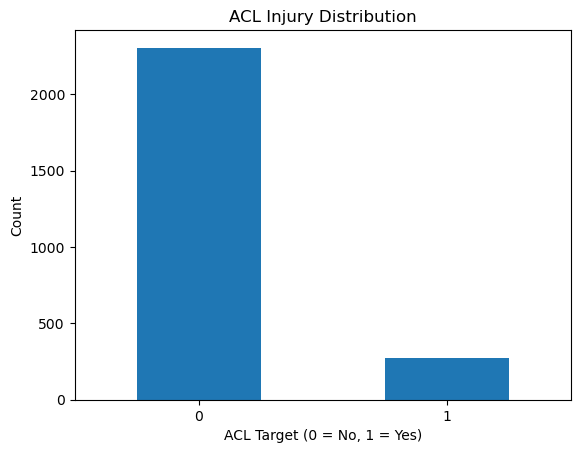

In [131]:
df["acl_target"].value_counts().plot(kind="bar")
plt.title("ACL Injury Distribution")
plt.xlabel("ACL Target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

##### The dataset is highly imbalanced, with significantly fewer ACL cases compared to non-ACL cases

In [132]:
# original files were corrupted when processing so we restore the original 
# height and weight colums from the original data

# restore from raw 
df["height_m"] = df_raw[6]
df["weight_kg"] = df_raw[5]

# clean height
df["height_m"] = (
    df["height_m"]
    .astype(str)
    .str.replace("\xa0", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .replace("-", np.nan)
)
df["height_m"] = pd.to_numeric(df["height_m"], errors="coerce")

# clean weight
df["weight_kg"] = (
    df["weight_kg"]
    .astype(str)
    .str.replace("\xa0", "", regex=False)
    .str.strip()
    .replace("-", np.nan)
)

#preview height & weight
df["weight_kg"] = pd.to_numeric(df["weight_kg"], errors="coerce")

df[["weight_kg", "height_m"]].head()

,weight_kg,height_m
0,89.0,1.88
1,84.0,1.84
2,NaN,1.98
3,69.0,1.88
4,85.0,1.91


Here we chose to demonstrate the relationship between the height and weight of the subjects:


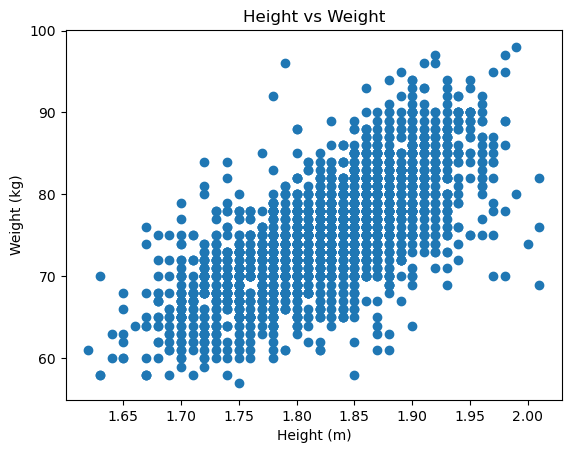

In [133]:
plt.scatter(df["height_m"], df["weight_kg"])
plt.title("Height vs Weight")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.show()

In [134]:
# convert date to age 
df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")

today = pd.Timestamp.today()
df["age"] = ((today - df["birth_date"]).dt.days / 365.25).round(1)

df[["age"]].head()

,age
0,32.6
1,43.0
2,27.4
3,31.9
4,31.9


Player age distribution : 

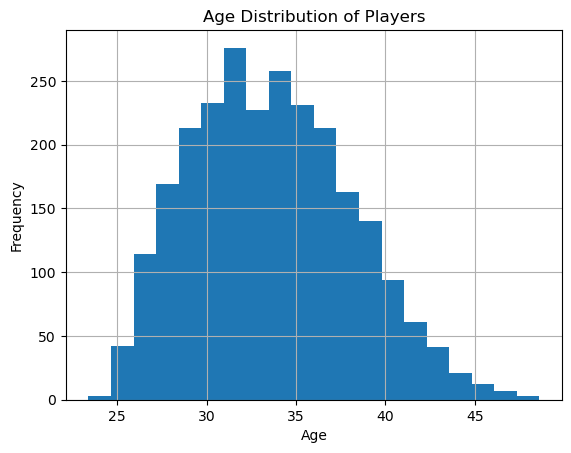

In [135]:
df["age"].hist(bins=20)
plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [136]:
# Final Dataset for Modeling
#Dropped all irrelevant colums

df_model = df.drop(columns=[
    "player_id",
    "name",
    "birth_date",
    "transfer_history",
    "injury_history"
])

df_model.head()

,club,market_value,weight_kg,height_m,country,position,preferred_foot,acl_target,age
0,Manchester City,"1,14 Bill. €",89.0,1.88,Brazil,Goalkeeper,left,0,32.6
1,Manchester City,"1,14 Bill. €",84.0,1.84,Chile,Goalkeeper,right,0,43.0
2,Manchester City,"1,14 Bill. €",NaN,1.98,Kosovo,Goalkeeper,right,0,27.4
3,Manchester City,"1,14 Bill. €",69.0,1.88,England,Defender - Centre-Back,right,0,31.9
4,Manchester City,"1,14 Bill. €",85.0,1.91,France,Defender - Centre-Back,left,0,31.9


In [137]:
# Creating features and target variable
X = df_model.drop(columns=["acl_target"])
y = df_model["acl_target"]

In [138]:
# Preprocessing Pipeline for numerical and categorical features
categorical_features = ["club", "market_value", "country", "position", "preferred_foot"]
numerical_features = ["weight_kg", "height_m", "age"]

#fill missingvalues with median
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#fill missing value with most frequent keyword
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#combine everything
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Train-test split
# 75 training 25 percent testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [139]:
#Logistic Regression

log_model = Pipeline([
    ("preprocessor", preprocessor),
    (("model", LogisticRegression(max_iter=1000, class_weight="balanced")))
])

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6341085271317829
Precision: 0.1187214611872146
Recall: 0.37681159420289856
F1: 0.18055555555555555
[[383 193]
 [ 43  26]]


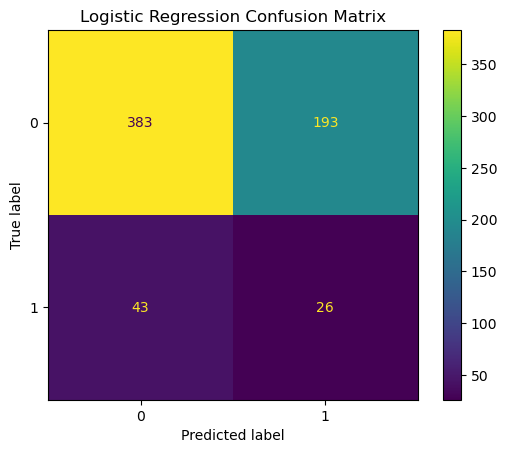

In [154]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Logistic Regression Results
Using class balancing improved the model's ability to detect ACL-positive cases. Although accuracy decreased compared to the unbalanced model, recall improved substantially, which is important because the original model failed to identify almost any positive cases. However, precision remains low, indicating that many non-ACL players are still being classified as ACL-positive.

In [140]:
# KNN
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1:", f1_score(y_test, y_pred_knn, zero_division=0))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, zero_division=0))

KNN Results
Accuracy: 0.8868217054263566
Precision: 0.3
Recall: 0.043478260869565216
F1: 0.0759493670886076
[[569   7]
 [ 66   3]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       576
           1       0.30      0.04      0.08        69

    accuracy                           0.89       645
   macro avg       0.60      0.52      0.51       645
weighted avg       0.83      0.89      0.85       645



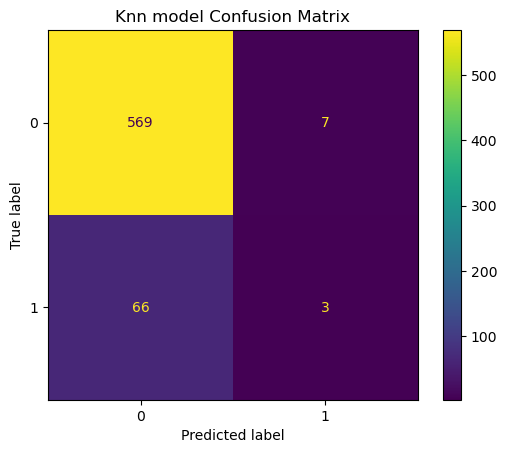

In [158]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test)
plt.title("Knn model Confusion Matrix")
plt.show()

In [142]:
# SVM
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(class_weight="balanced"))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm, zero_division=0))
print("F1:", f1_score(y_test, y_pred_svm, zero_division=0))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, zero_division=0))

SVM Results
Accuracy: 0.7782945736434108
Precision: 0.2153846153846154
Recall: 0.4057971014492754
F1: 0.2814070351758794
[[474 102]
 [ 41  28]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       576
           1       0.22      0.41      0.28        69

    accuracy                           0.78       645
   macro avg       0.57      0.61      0.58       645
weighted avg       0.84      0.78      0.81       645



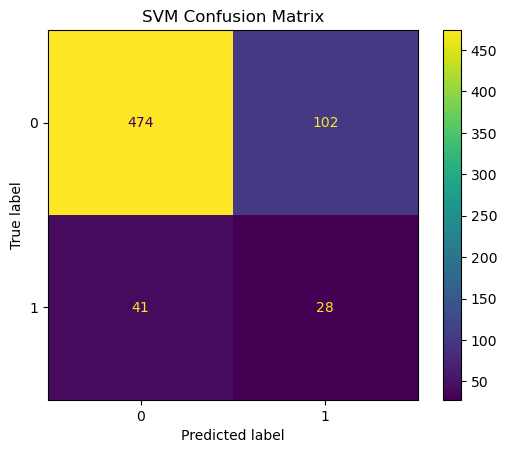

In [153]:
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)
plt.title("SVM Confusion Matrix")
plt.show()

The confusion matrix provides insight into the types of prediction errors made by the model. While the model is able to correctly identify some ACL cases, it also produces false positives and misses some true cases. This highlights the trade-off between recall and precision in an imbalanced classification problem.

In [144]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "F1": f1_score(y_test, y_pred_knn, zero_division=0)
    },
    {
        "Model": "SVM",
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
        "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
        "F1": f1_score(y_test, y_pred_svm, zero_division=0)
    }
])

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,SVM,0.778295,0.215385,0.405797,0.281407
0,Logistic Regression,0.634109,0.118721,0.376812,0.180556
1,KNN,0.886822,0.300000,0.043478,0.075949


# Model Comparision 
As we can observe using the graph, the SVM model is the most accurate in predicting the ACL injuries as it has the highest F1 score 

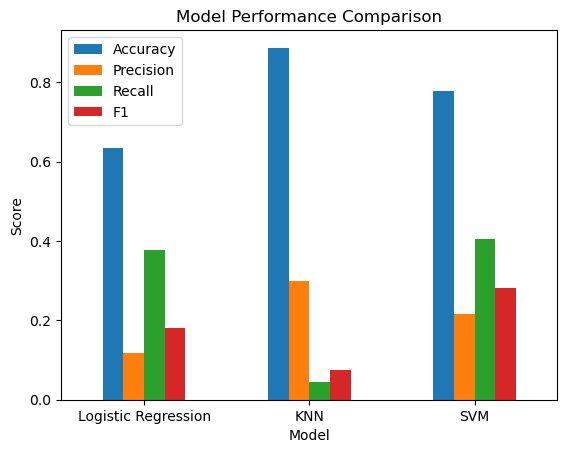

In [145]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()